In [1]:
import rastereasy

# Read geoimage

In `rastereasy`, one of the main class to deal with georeferenced images is `Geoimage`. It contains the main functions (for resampling, reprojection, stack, plotting, ...). Let's start by opening and plotting an image, some bands or making color compositions

# Open an image

## Read basic information of the image, without open it (parameter `meta_only=True`)

In [2]:
name_im='./data/demo/sentinel.tif'
image=rastereasy.Geoimage(name_im,meta_only=True)

In [3]:
# Alternatively, we can give names to bands
names = {"NIR":8,"G":3,"CO" : 1,"SWIR2":11,"B": 2,"R":4,"RE1":5,"RE2":6,"RE3":7,"WA":9,"SWIR1":10,"SWIR3":12}
image_names=rastereasy.Geoimage(name_im,names=names)


## General information

The function `ìnfo()` gives general informations on the opened image

In [4]:
image.info()
image_names.info()

- Size of the image:
   - Rows (height): 1000
   - Cols (width): 1000
   - Bands: 12
- Spatial resolution: 10.0  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.04099599, 38.39058840)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:32637
- Nodata: -32768.0

- Given names for spectral bands: 
   {'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12}


- Size of the image:
   - Rows (height): 1000
   - Cols (width): 1000
   - Bands: 12
- Spatial resolution: 10.0  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.04099599, 38.39058840)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:32637
- Nodata: -32768.0

- Given names for spectral bands: 
   {'CO': 1, 'B': 2, 'G': 3, 'R': 4, 'RE1': 5, 'RE2': 6, 'RE3': 7, 'NIR': 8, 'WA': 9, 'SWIR1': 10, 'SWIR2': 11, 'SWIR3': 12}




## Open an entire image

See help for initializing a `Geoimage`

In [5]:
help(rastereasy.Geoimage.__init__)

Help on function __init__ in module rastereasy_dev:

__init__(self, source_name=None, meta_only=False, names=None, history=False, data=None, meta=None, georef=None, target_crs='EPSG:4326', area=None, extent='pixel')
    Initialize a Geoimage object from a file or data array with metadata.
    
    Parameters
    ----------
    source_name : str, optional
        Path to a geoimage (.tif, .jp2) image file to load. 
        If provided, the image data and metadata 
        will be read from this file.
    meta_only : bool, optional
        If True, do not read the image but just
        the meta information (useful for image.info()).
    names : dict, optional
        Dictionary mapping band names to 
        band indices (e.g., {'NIR': 1, 'R': 2, 'G': 3}).
        If not provided, bands will be 
        named numerically ('1', '2', '3', ...).
    area : tuple, optional
        To read  only a window of the image
            If based on pixel coordinates, you must indicate 
            -

In [6]:
name_im='./data/demo/sentinel.tif'
image=rastereasy.Geoimage(name_im)

## Make a color composition 

See the dedicated example. By default, the three first bands are used

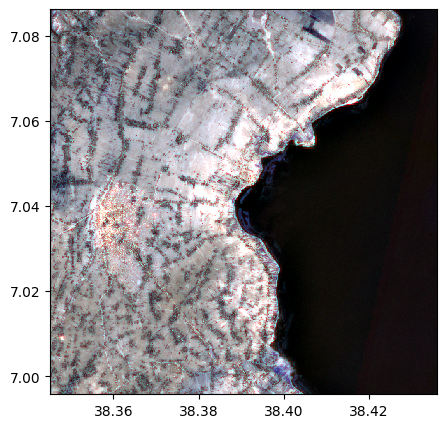

In [7]:
# By default, coordinates are lat/lon 
image.colorcomp()

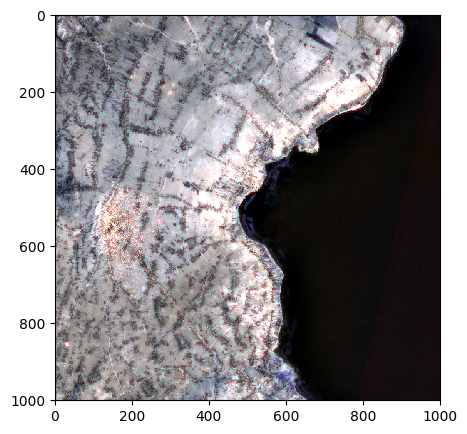

In [8]:
# To have coordinates in pixel
image.colorcomp(extent='pixel')

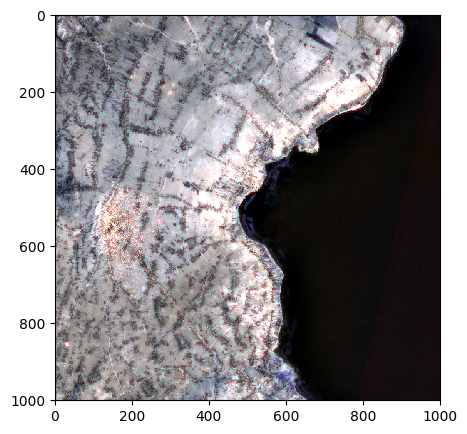

In [9]:
# To remove coordinates 
image.colorcomp(extent='pixel')

## Open a window of the image based on pixel coordinates

You must indicate 
- the row/col coordinades of the north-west corner (deb_row,deb_col)
- the row/col coordinades of the south-east corner (end_row,end_col)
  
in a tuple  `((deb_row,end_row),(deb_col,end_col))`

- Size of the image:
   - Rows (height): 677
   - Cols (width): 410
   - Bands: 12
- Spatial resolution: 10.0  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.05240988, 38.36748819)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:32637
- Nodata: -32768.0

- Given names for spectral bands: 
   {'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12}




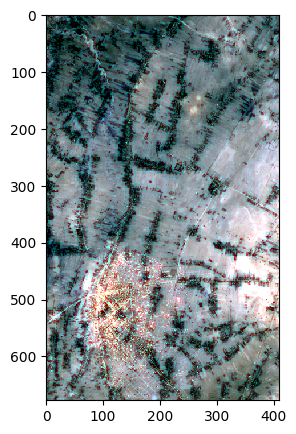

In [10]:
deb_row=35
end_row=712
deb_col=40
end_col=450
area_pixel=((deb_row,end_row),(deb_col,end_col))
image=rastereasy.Geoimage(name_im,area=area_pixel)
image.info()
image.colorcomp(extent='pixel')

## Open a window of the image based on longitude / latitude coordinates


You must indicate 
- the lat/lon coordinades of the north-west corner (lat1,lon1)
- the lat/lon coordinades of the south-east corner (lat2,lon2)
  
in a tuple  `((lon1,lon2),(lat1,lat2))`


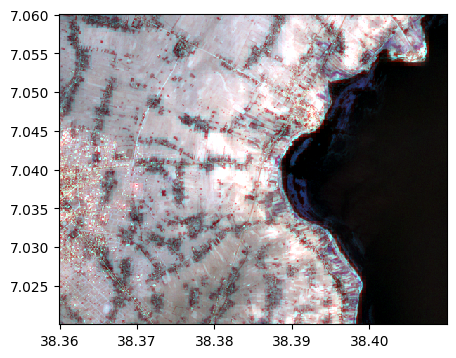

In [11]:
lat1=7.06
lat2=7.02
lon1=38.36
lon2=38.41
area_ll=((lon1,lon2),(lat1,lat2))
image_window_latlon=rastereasy.Geoimage(name_im,area=area_ll,extent='latlon')
image_window_latlon.colorcomp()

# Save an image

The function `.save()` enables to save an image

In [12]:
image_names.save('./data/results/save/save_image.tif')

Now we can reload it

In [13]:
image_reloaded=rastereasy.Geoimage('./data/results/save/save_image.tif')
image_reloaded.info()

- Size of the image:
   - Rows (height): 1000
   - Cols (width): 1000
   - Bands: 12
- Spatial resolution: 10.0  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.04099599, 38.39058840)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:32637
- Nodata: -32768.0

- Given names for spectral bands: 
   {'CO': 1, 'B': 2, 'G': 3, 'R': 4, 'RE1': 5, 'RE2': 6, 'RE3': 7, 'NIR': 8, 'WA': 9, 'SWIR1': 10, 'SWIR2': 11, 'SWIR3': 12}




# Read some informations

Apart from the `.info()` function,   `get_meta()` outputs rasterio metadata

In [14]:
image_names.get_meta()

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -32768.0,
 'width': 1000,
 'height': 1000,
 'count': 12,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 37N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32637"]]'),
 'transform': Affine(10.0, 0.0, 427690.0,
        0.0, -10.0, 783330.0)}

To get some more useful information

In [15]:
print('number of bands = ',image.nb_bands)
print('shape = ',image.shape)
print('spatial resolution = ',image.resolution)
print('lat / lon of central pixel = ',image.get_latlon_coordinates())

number of bands =  12
shape =  (677, 410)
spatial resolution =  10.0
lat / lon of central pixel =  (7.052409883832736, 38.367488186916184)


## Values in the image

### Values in some pixel locations

In [16]:
image=rastereasy.Geoimage(name_im)
# Extract the specrum in pixel 309,223
image[309,223]


array([ 867, 1144, 1456, 1960, 2246, 2324, 2444, 2380, 2566, 2597, 3252,
       3149], dtype=int16)

In [17]:
# Extract the specra in all cols of line 309
image[309,:]


array([[ 514,  514,  514, ...,  257,  257,  257],
       [ 751,  758,  596, ...,  269,  279,  281],
       [1084, 1112,  898, ...,  484,  483,  480],
       ...,
       [3079, 3079, 3079, ...,  187,  187,  187],
       [2775, 2555, 2555, ...,  147,  147,  147],
       [2399, 2000, 2000, ...,  115,  115,  117]],
      shape=(12, 1000), dtype=int16)

In [18]:
# Extract the image in band 3
image[:,:][3]

array([[ 567,  645,  690, ...,  324,  322,  335],
       [ 579,  590,  608, ...,  346,  342,  335],
       [ 558,  610,  645, ...,  338,  334,  327],
       ...,
       [1518, 1750, 1694, ...,  339,  348,  350],
       [1534, 1652, 1688, ...,  346,  342,  342],
       [1636, 1694, 1750, ...,  347,  339,  336]],
      shape=(1000, 1000), dtype=int16)

In [19]:
# all spectral values in a given pixel
row=20
col=10
print('spectral values in',row,',',col,' : ',image[row,col])
print('size of all spectral values in row',row,':', image[row,:].shape)
print('size of all spectral values in col',col,':', image[:,col].shape)
# check consistency
pixel_row = 15
pixel_col = 22
print('diff with table with values at row ',row,' in pixel col',pixel_col,':', image[row,:][:,pixel_col]-image[row,pixel_col])
print('diff with table with values at col ',col,' in pixel row',pixel_row,':', image[:,col][:,pixel_row]-image[pixel_row,col])


spectral values in 20 , 10  :  [ 499  542  869  813 1591 3169 3654 3717 3856 3704 2732 1716]
size of all spectral values in row 20 : (12, 1000)
size of all spectral values in col 10 : (12, 1000)
diff with table with values at row  20  in pixel col 22 : [0 0 0 0 0 0 0 0 0 0 0 0]
diff with table with values at col  10  in pixel row 15 : [0 0 0 0 0 0 0 0 0 0 0 0]


## Min, Max, Sum, Mean, Std, Median, ...

### Global values

In [20]:
# Let's crop the image to have different shapes in row/col
image=rastereasy.Geoimage(name_im)
image.crop(10,100,50,70,inplace=True)
print('Shape of the image (lig x col) : ',image.shape)
print('Number of channels of the image : ',image.nb_bands)



Shape of the image (lig x col) :  (90, 20)
Number of channels of the image :  12


In [21]:
### Global min, max, std, ...
print('Global minimum of the image', image.min())
print('Global minimum of the image', image.max())
print('Global std of the image', image.std())
print('Global mean of the image', image.mean())
print('Global median of the image', image.median())
print('Global sum of the image', image.sum())

Global minimum of the image 273
Global minimum of the image 3836
Global std of the image 890.1268204217575
Global mean of the image 1958.3739814814815
Global median of the image 2261.0
Global sum of the image 42300878


### Values per row, col, band, pixel

In [22]:
help(image.min)

Help on method min in module rastereasy_dev:

min(axis=None) method of rastereasy_dev.Geoimage instance
    Calculate the minimum value along a specified axis.
    
    Parameters
    ----------
    axis : {'band', 'row', 'col', None}, optional
        The axis along which to compute the minimum:
        - 'band': Minimum across spectral bands for each pixel
        - 'row': Minimum across rows (lines) for each band and column
        - 'col': Minimum across columns for each band and row
        - 'pixel': Minimum across pixels for each bands
        - None: Global minimum of the entire image
        Default is None.
    
    Returns
    -------
    float or numpy.ndarray
        - If axis=None: A single value representing the global minimum
        - If axis='band': Array with shape (nb_rows,nb_cols) containing  mins along bands
        - If axis='row': Array with shape (nb_bands,nb_cols) containing mins along rows
        - If axis='col': Array with shape (nb_bands,nb_rows) containin

In [23]:
for axis in ['band','row','col','pixel']:
    mini=image.min(axis=axis)
    print('Minimum on axis ',axis, 'gives a numpy table of size',mini.shape)


Minimum on axis  band gives a numpy table of size (90, 20)
Minimum on axis  row gives a numpy table of size (12, 20)
Minimum on axis  col gives a numpy table of size (12, 90)
Minimum on axis  pixel gives a numpy table of size (12,)


As we can see in the help, 
- If `axis=None`: A single value representing the global minimum
- If `axis='band'`: Array with shape `(nb_rows,nb_cols)` containing  mins along bands
- If `axis='row'`: Array with shape `(nb_bands,nb_cols)` containing mins along rows
- If `axis='col'`: Array with shape `(nb_bands,nb_rows)` containing  mins along cols
- If `axis='pixel'`: Array with shape `(nb_bands,)` containing  mins along all pixels for each band


The same holds for `max`, `sum`, `mean`, `median`

In [24]:
print('Overall min  of the image along the channels : ',image.min(axis='pixel'),'\n')
# As we can see, we have 12 values corresponding to the minimum in each image'

Overall min  of the image along the channels :  [ 372  273  557  497 1066 1878 1953 1830 2143 2456 2106 1329] 



In [25]:
help(image.max)
print('Maximum  of the image for each band: ', image.max(axis = 'band'),'\n')


Help on method max in module rastereasy_dev:

max(axis=None) method of rastereasy_dev.Geoimage instance
    Calculate the maximum value along a specified axis.
    
    Parameters
    ----------
    axis : {'band', 'row', 'col', None}, optional
        The axis along which to compute the maximum:
        - 'band': Maximum across spectral bands for each pixel
        - 'row': Maximum across rows (lines) for each band and column
        - 'col': Maximum across columns for each band and row
        - 'pixel': Maximum across pixels for each bands
        - None: Global maximum of the entire image
        Default is None.
    
    Returns
    -------
    float or numpy.ndarray
        - If axis=None: A single value representing the global maximum
        - If axis='band': Array with shape (nb_rows,nb_cols) containing  max along bands
        - If axis='row': Array with shape (nb_bands,nb_cols) containing max along rows
        - If axis='col': Array with shape (nb_bands,nb_rows) containing 

# Plot image (colorcomp or bands)

## Note on axes (pixel vs latlong)


By default, rastereasy plots images using latitude and longitude coordinates. If you want to plot with pixel coordinates, put the parameter `extent = 'pixel'`

## Color composition via `colorcomp` function

In [26]:
image=rastereasy.Geoimage(name_im)
help(image.colorcomp)

Help on method colorcomp in module rastereasy_dev:

colorcomp(bands=None, dest_name='', percentile=2, fig_size=(5, 5), title='', extent='latlon') method of rastereasy_dev.Geoimage instance
    Create and display a color composite image from selected bands.
    
    This method creates an RGB color composite by assigning three bands to the red,
    green, and blue channels. It's useful for creating false color compositions,
    natural color images, or any three-band visualization.
    
    Parameters
    ----------
    bands : list of str, optional
        List of three band identifiers to use for the RGB composite (in order: R, G, B).
        Can be band names (e.g., ["NIR", "R", "G"]) or indices (e.g., ["4", "3", "2"]).
        If None, uses the first three bands in the image.
        Default is None.
    
    dest_name : str, optional
        Path to save the color composite image. If empty, the image is not saved.
        Default is ''.
    
    percentile : int, optional
        P

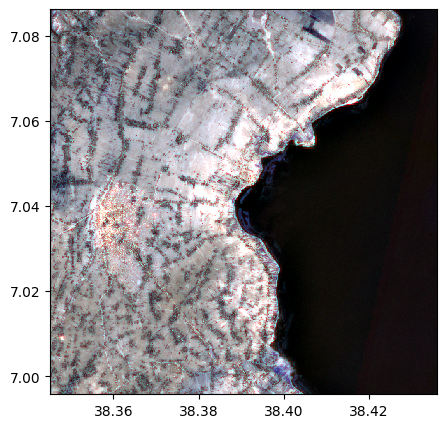

In [27]:
# colorcomp with 3 first bands
image.colorcomp()

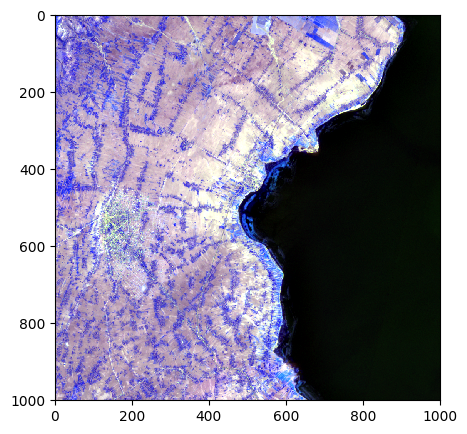

In [28]:
image.colorcomp(bands=['4','3','6'],extent = 'pixel')

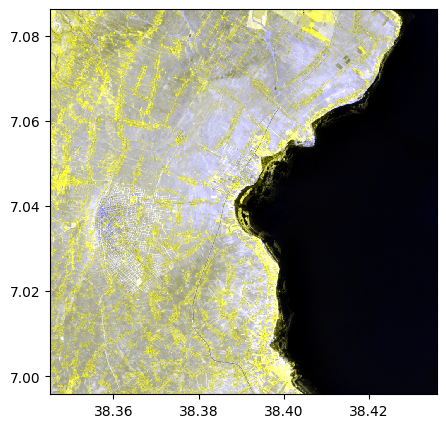

In [29]:
image.colorcomp(bands=[8,8,3])

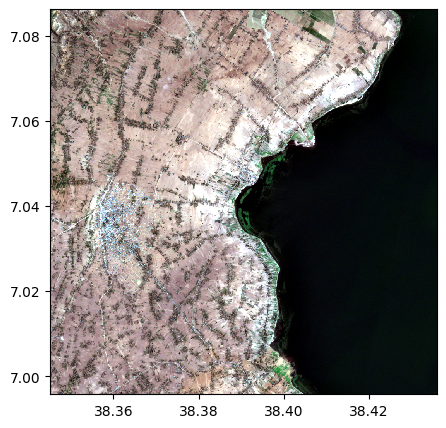

In [30]:
image_names.colorcomp(bands=["R","G","B"],dest_name='./data/results/colorcomp/S2_colorcomp_R_G_B.tif')

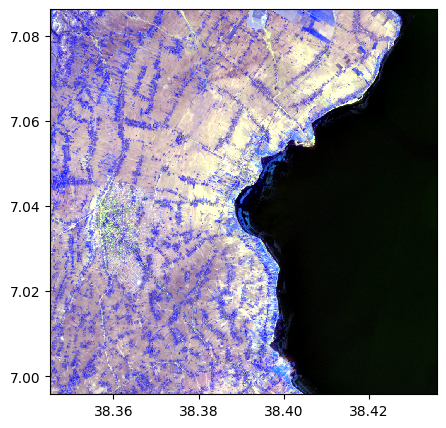

In [31]:
image_names.colorcomp(bands=["R","G","NIR"],dest_name='./data/results/colorcomp/test_colorcomp_R_G_NIR.tif')

## By bands

In [32]:
help(image.visu)

Help on method visu in module rastereasy_dev:

visu(bands=None, title='', percentile=0, fig_size=(5, 5), cmap=None, colorbar=False, extent='latlon') method of rastereasy_dev.Geoimage instance
    Visualize one or more bands of the image.
    
    This method provides a flexible way to display individual bands or multiple bands
    as separate figures. Unlike colorcomp, which creates RGB composites, this method
    displays each band in grayscale or with a specified colormap.
    
    Parameters
    ----------
    bands : str, list of str, or None, optional
        The bands to visualize:
        - If None: Displays all bands separately
        - If a string: Displays a single specified band
        - If a list: Displays each specified band separately
        Default is None.
    
    title : str, optional
        Base title for the visualization. Band names will be appended.
        Default is ''.
    
    percentile : int, optional
        Percentile value for contrast stretching (e.g

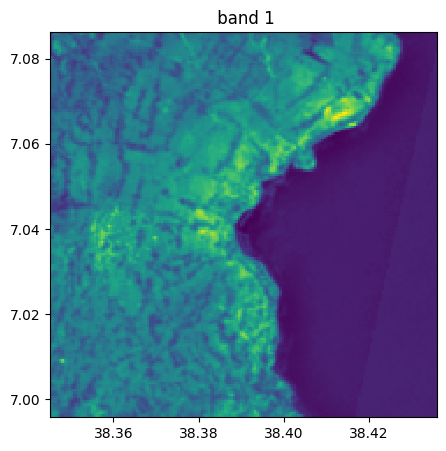

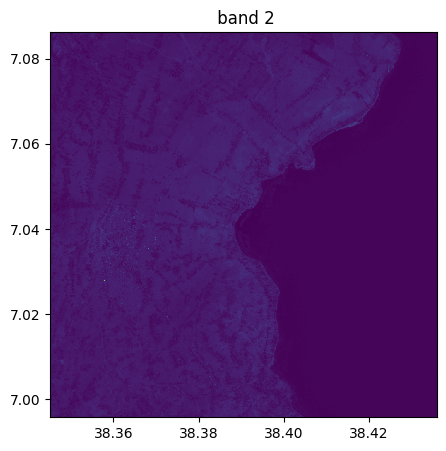

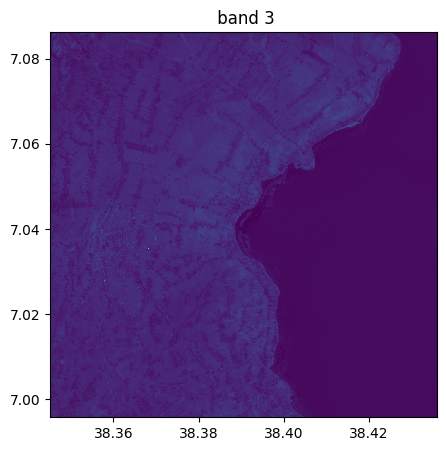

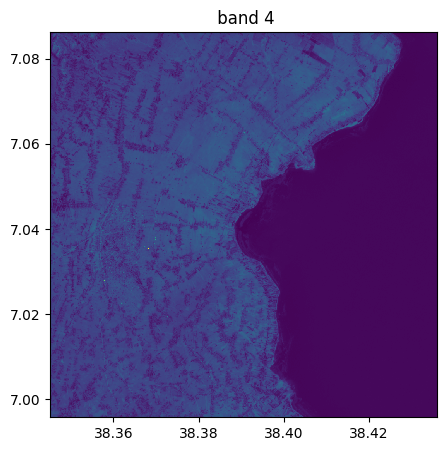

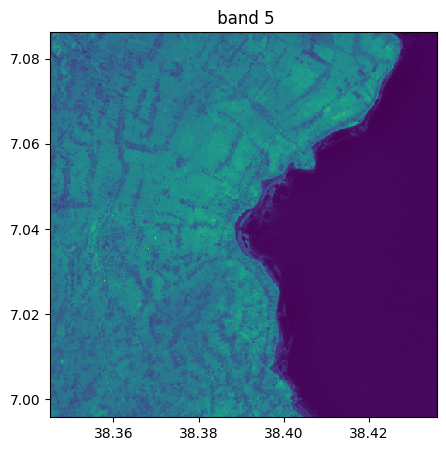

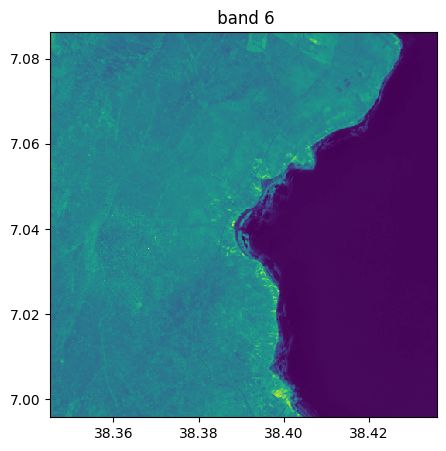

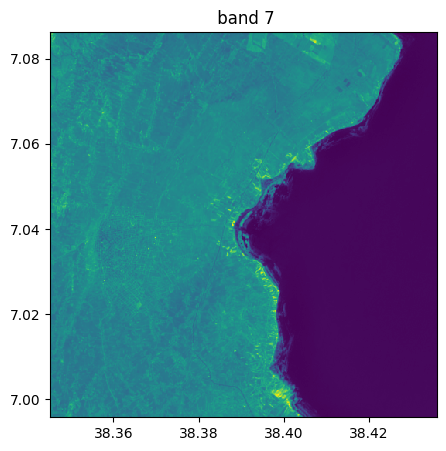

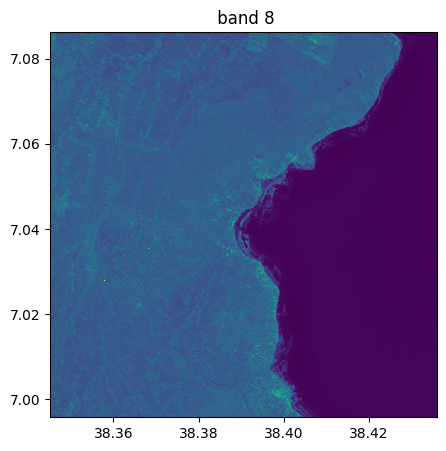

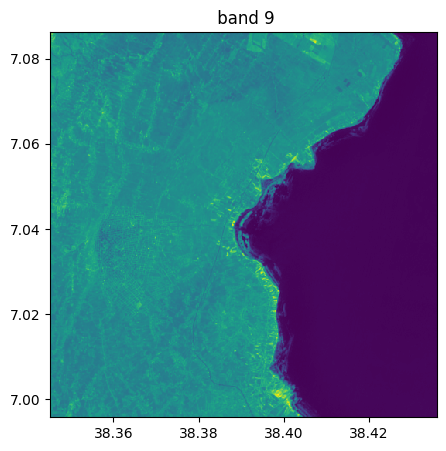

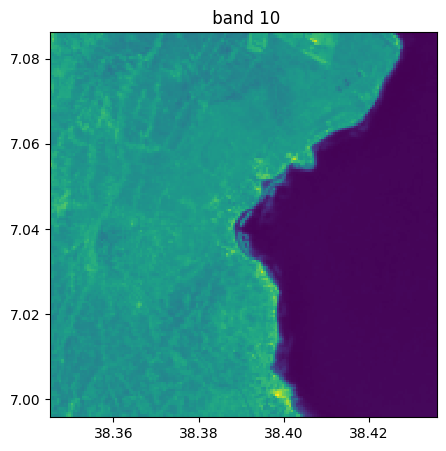

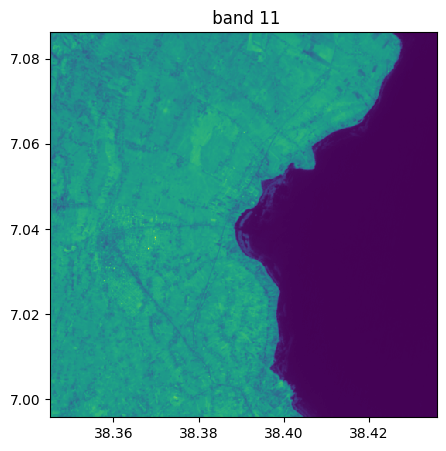

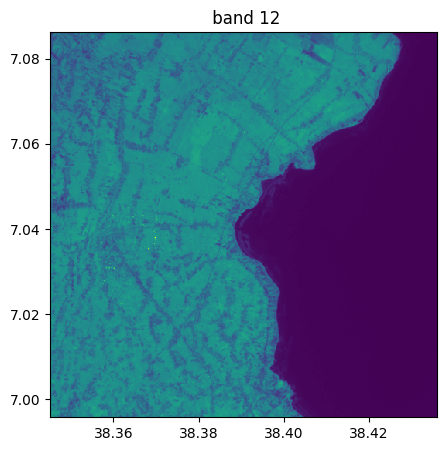

In [33]:
image.visu(fig_size=(5,5))

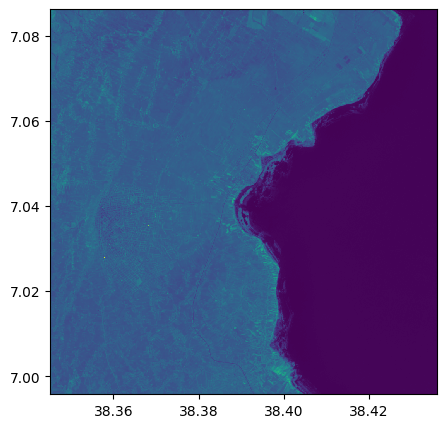

In [34]:
image.visu(bands=8)

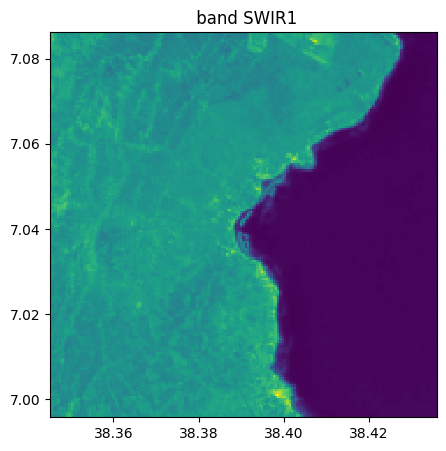

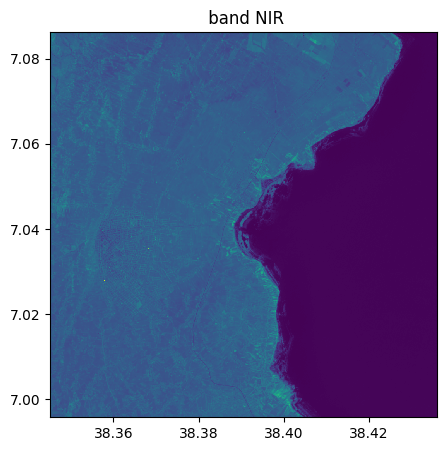

In [35]:
image_names.visu(["SWIR1","NIR"])

# Histograms

In [36]:
help(image.hist)

Help on method hist in module rastereasy_dev:

hist(**args) method of rastereasy_dev.Geoimage instance
    Display histograms of the image data.
    
    This method provides a flexible way to visualize the distribution of pixel values
    in one or more bands of the image. It supports various customization options for
    the histogram display.
    
    Parameters
    ----------
    bands : str, int, list, optional
        The bands to visualize. If not specified, all bands are included.
        This can be band names (e.g., ["NIR", "R", "G"]) or indices (e.g., [4, 3, 2]).
    
    superpose : bool, optional
        If True, all histograms are plotted on the same figure. If False (default),
        each band gets its own separate histogram figure.
    
    bins : int, optional
        The number of bins for computing the histogram. Default is 100.
    
    xmin : float, optional
        The minimum value to plot on the x-axis. Values lower than this won't be displayed.
    
    xmax :

### By bands

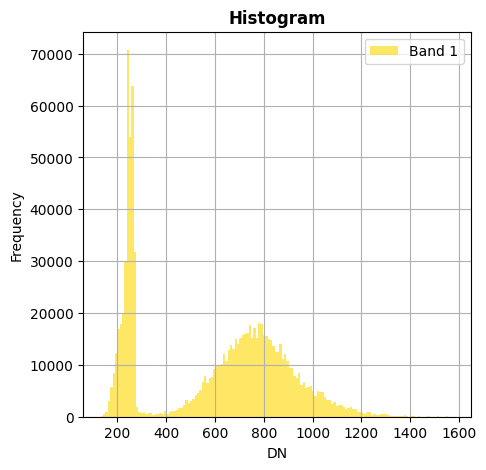

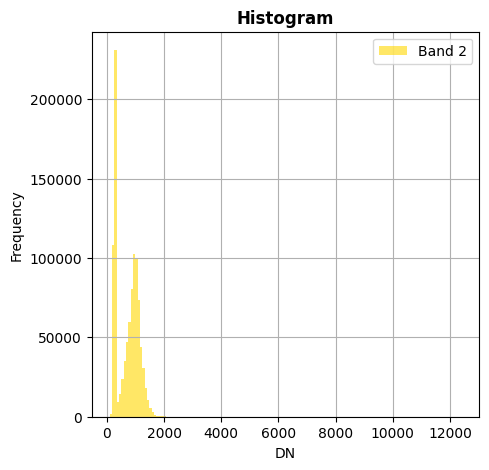

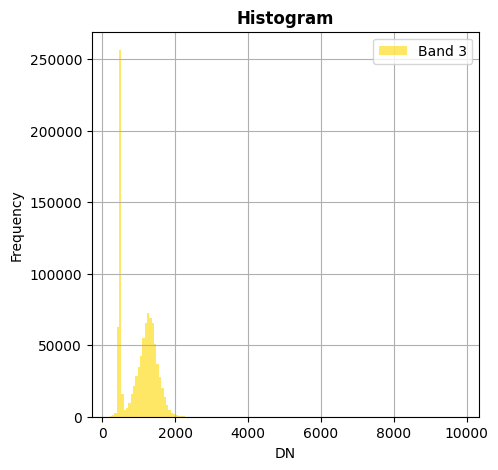

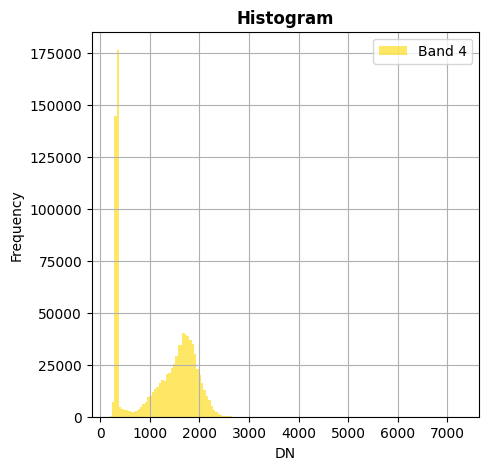

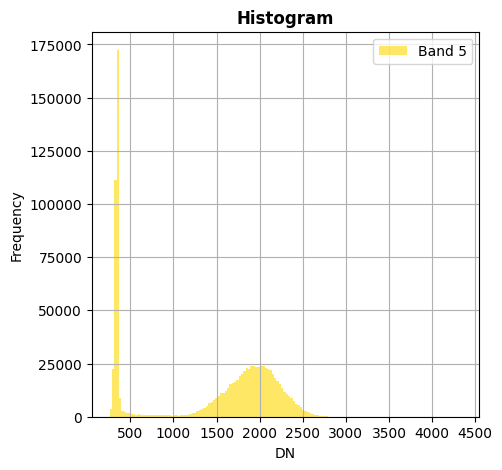

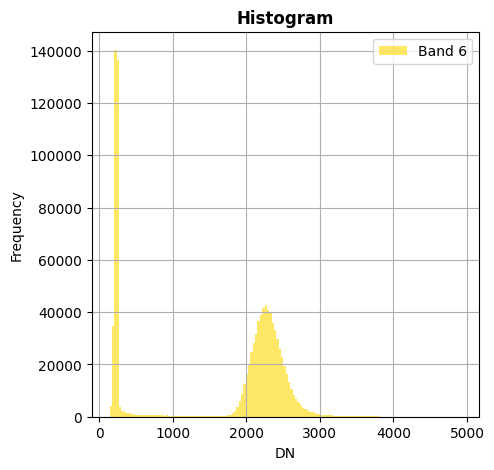

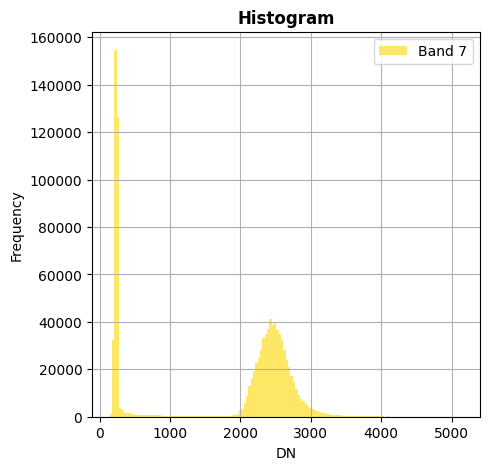

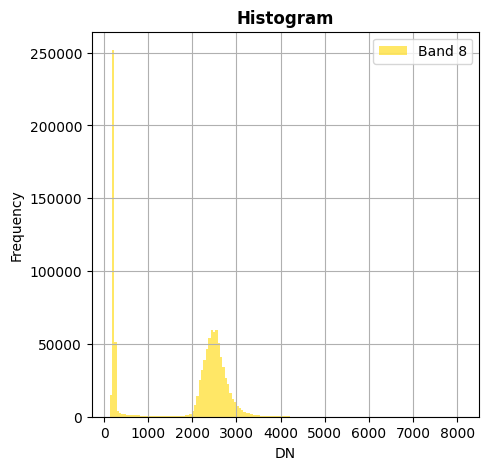

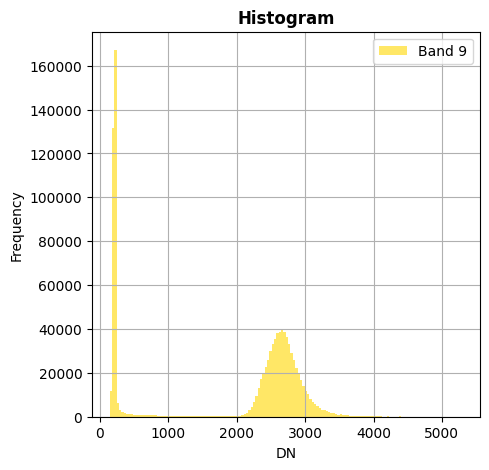

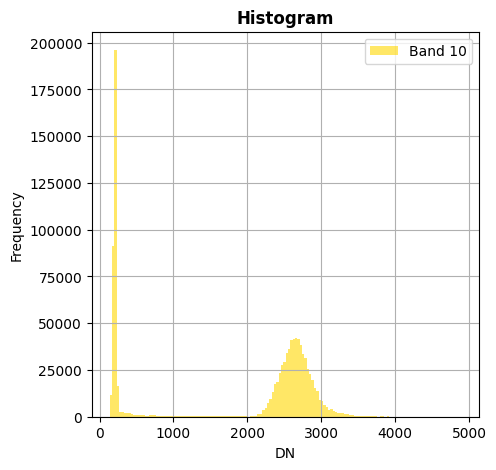

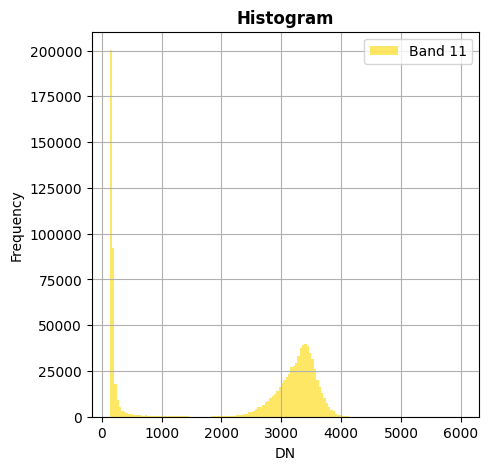

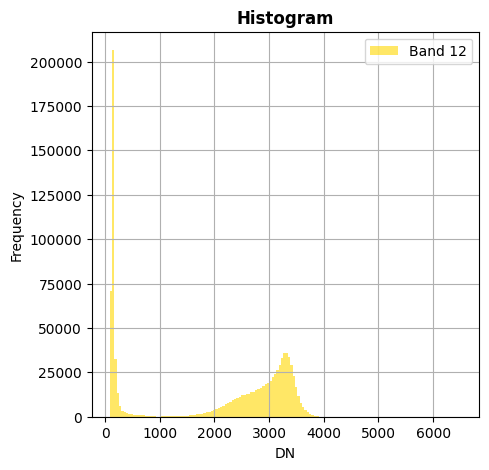

In [37]:
# Show all bands
image.hist(bins=150,histtype='stepfilled',fig_size=(5,5))

### Superposition of bands

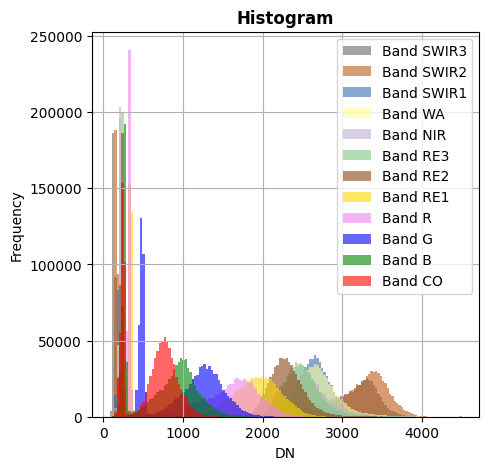

In [38]:
image_names.hist(bins=150,histtype='stepfilled',superpose=True, xmax=4500)

### Show only some bands

#### Without superposition

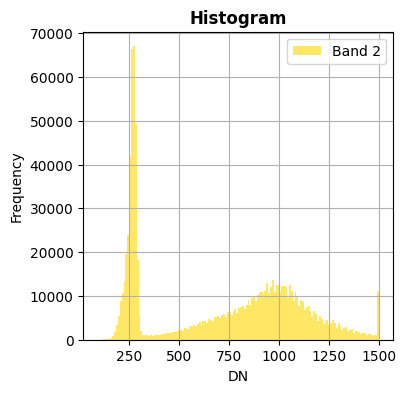

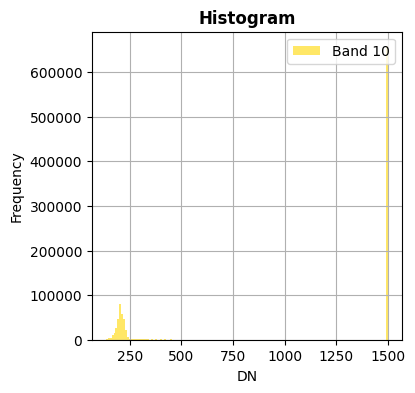

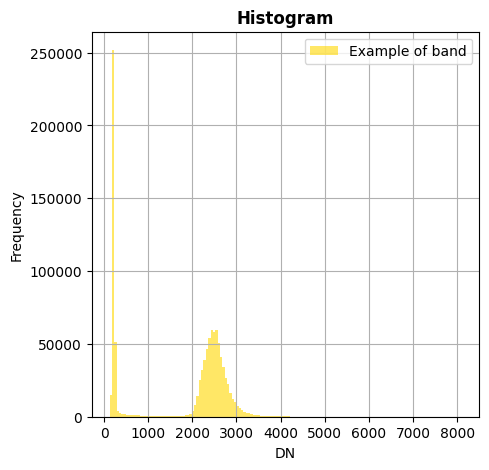

In [39]:
image.hist(bands=["2","10"],bins=150,histtype='stepfilled',fig_size=(4,4),xmax=1500)
image.hist(bands=8,bins=150,histtype='stepfilled',label='Example of band')

#### With superposition

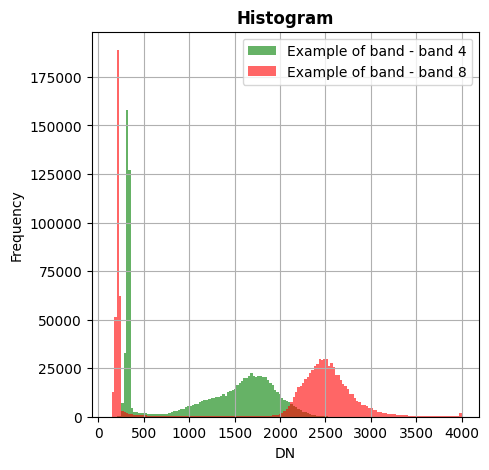

In [40]:
image.hist(bands=[8,4],bins=150,histtype='stepfilled',label='Example of band',superpose=True,xmin=0,xmax=4000)

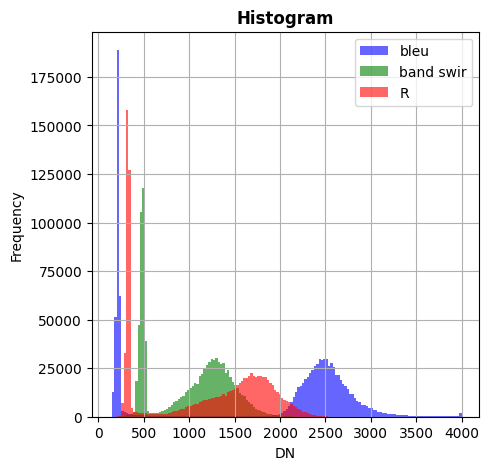

In [41]:
image_names.hist(bands=["R","G","NIR"],bins=150,histtype='stepfilled',superpose = True,label=["R","band swir","bleu"],xmax=4000)